# <img src="https://i.imgur.com/1voq3gc.png" width=100 height=100, style="vertical-align:middle;margin:0px 12px"/> Assignment 5
---

<!-- Disclaim: Please note that the examples there are for demonstration purposes only to introduce basic tools and functions which might be helpful in future when one wish to start working with their own research project.  -->

## Environment Setup 
---

### Development Environment Setup
Make sure to read [Development Setup Guideline](https://moodle.oulu.fi/pluginfile.php/2761255/mod_resource/content/2/Development_setup_guideline.pdf) for development environment setup. 

This assignment consists of the following files:

- Main notebook: `Assignment_5.ipynb`
- Data: data_assignment4.csv (assignment 2 included OAI data access and tasks related to that data, so you can have a look on assignment 2)

For those who use Google Colab, upload those files to your `Colab Notebooks` folder on `Google Drive`.

### Submission

- Rename the notebook with solutions from `Assignment_5.ipynb` --> `<First name>.<Last name>.Assignment_5.ipynb`
- For more details, reference to the [FAQs page](https://moodle.oulu.fi/mod/page/view.php?id=1788245)
- Note: Only submit the notebook with solutions in .ipynb format. Do NOT compress it.


### Any questions
- Reference to [FAQs page](https://moodle.oulu.fi/mod/page/view.php?id=1788245).
- Or post your questions to [Q&A forum](https://moodle.oulu.fi/mod/forum/view.php?id=1755240).

---
# Prerequisite: OAI Data Access Permission
Before proceeding with this assignment, ensure that you have obtained access to the **OAI dataset**.

Follow the instruction in the [Guideline](https://moodle.oulu.fi/mod/assign/view.php?id=1794354) to obtain access permission to the OAI dataset. 

- If you have **not** previously submitted an access request, this step is **mandatory**.  
- If you **already have access**, you may **skip this step** and proceed with the assignment. 

---
# **Modeling in different scenarios (15pts)**

🎯 Goals: You will learn how to choose suitable modeling approach in different scenarios and how to extract meaningfull information from your fitted model.

---

#### **Data Introduction**  

In this assignment, we provide a **preprocessed dataset**, `data_assignment5.csv`, containing data from 3,433 participants. For each participant, a random knee was selected at baseline.  

The dataset consists of 9 columns: **`ID`**, **`SIDE`**, **`Site`**, **`SEX`**, **`AGE`**, **`BMI`**, **`INJURY`**, **`KL`**, and **`JSW`**.  

While some variables (**`ID`**, **`Site`**, **`SEX`**, **`AGE`**, and **`BMI`**) have been introduced in previous assignments and lectures, we will focus on **three key variables** for this assignment:  

- **Kellgren and Lawrence (`KL`) grading system** is used to assess the severity of osteoarthritis (OA). It classifies OA into 5 levels (0–4) based on radiographic features.  

<div align="center">
<img src="https://www.researchgate.net/publication/359459364/figure/fig2/AS:11431281179347951@1691186606793/Examples-of-knee-osteoarthritis-images-and-the-corresponding-classification-criteria_W640.jpg" width="700"/>
</div>  
 
- **Joint Space Width (`JSW`)** is a common biomarker for tracking OA progression. It is measured from radiographs and divided into Medial JSW and Lateral JSW. In this assignment, we extracted medial JSW. For further details, please refer to the data description. 

<div align="center">
<img src="https://www.researchgate.net/publication/355019446/figure/fig1/AS:1075841551339520@1633512022164/Automatic-measurements-of-joint-space-width-JSW-medial-and-lateral-JSW-using.png" width="500"/>
</div>  


- **Injury History (`INJURY`)**: The **`INJURY`** variable indicates whether the selected knee has ever been badly injured. Please refer to the **data description** for more details.  

**Notes:** The variables **`KL`**, **`JSW`**, and **`INJURY`** were recorded during follow-up visits. Two knees of each participant was graded individually, thus there exists the **`SIDE`** column to differentiate them.  

---


In [3]:
# # Install the dependencies if required 
# %pip install numpy scipy pandas
# %pip install matplotlib seaborn
# %pip install statsmodels

In [27]:
#Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy
import statsmodels.api as sm
import statsmodels.formula.api as smf
import copy
# import pandas as pd
# import numpy as np
# import statsmodels.api as smf
from sklearn.preprocessing import StandardScaler

csv_path = Path(r"C:\Users\Hi\OneDrive - University of Oulu and Oamk\Documents\EBDS\Python for data statistics\Assignment_5\data_assignment5.csv")
df = pd.read_csv(csv_path)  
df.head(5)



,ID,SIDE,JSW,Visit,AGE,SEX,BMI,INJ,SURG,WOMAC,HEIGHT,WEIGHT,KL
0,9000099,R,4.32,0,59.0,1.0,23.8,0.0,0.0,14.000,1811.0,78.1,2.0
1,9000099,L,6.10,0,59.0,1.0,23.8,1.0,1.0,0.000,1811.0,78.1,3.0
2,9000296,R,5.44,0,69.0,1.0,29.8,0.0,0.0,0.000,1682.0,84.3,2.0
3,9000296,L,5.44,0,69.0,1.0,29.8,1.0,1.0,0.000,1682.0,84.3,3.0
4,9000622,R,4.20,0,71.0,0.0,22.7,0.0,0.0,20.875,1587.5,57.2,1.0


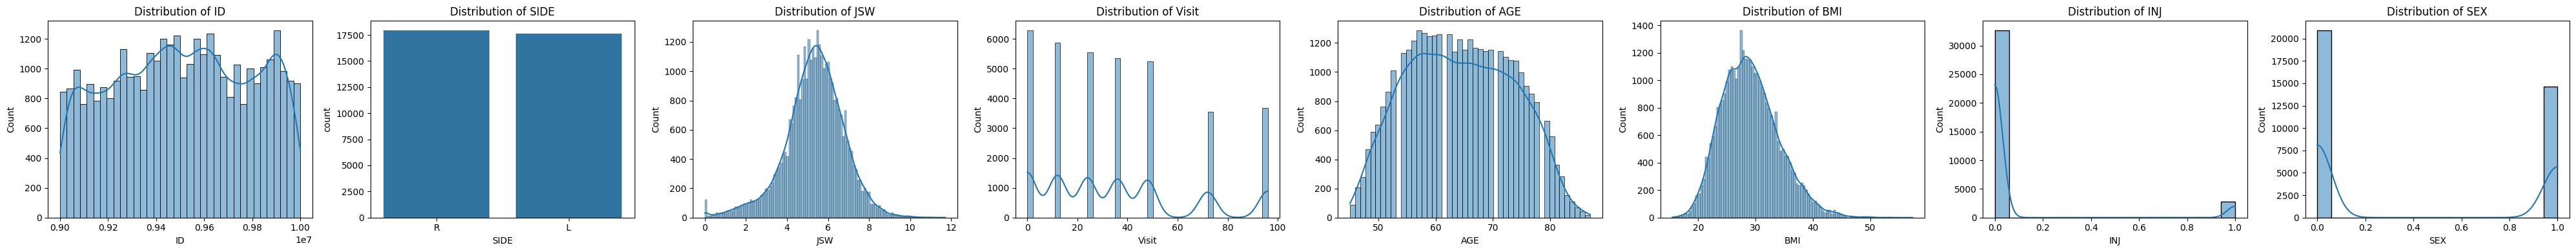

In [29]:
def plot_variables(df, variables):
    n_vars = len(variables)
    fig, axes = plt.subplots(1, n_vars, figsize=(5*n_vars, 4))
    if n_vars == 1:
        axes = [axes]  # Ensure axes is iterable
    
    for ax, var in zip(axes, variables):
        data = df[var].dropna()
        if var == 'SIDE':
            sns.countplot(x=data, ax=ax)
        else:
            sns.histplot(data, kde=True, ax=ax)
        ax.set_title(f'Distribution of {var}')
        ax.set_xlabel(var)
    
    plt.tight_layout()
    plt.show()

variables = ['ID', 'SIDE', 'JSW', 'Visit', 'AGE', 'BMI', 'INJ', 'SEX']
plot_variables(df, variables)

# not needed: 'SURG' WOMAC', 'HEIGHT', 'WEIGHT', 'KL'
# neded: 'ID', 'SIDE', 'JSW', 'Visit', 'AGE', 'SEX', 'BMI', 'INJ'

---
## **Task 1: Selecting a Statistical Model for Correlation Analysis (4 pts)** 

**Scenario**: You have data on left knees collected at baseline (Visit = 0). Your goal is to model the correlation between BMI, AGE, and JSW (Joint Space Width), with JSW as the response variable.

### **Task 1.1: Data Preprocessing (1pt)**
1. Filter the dataset to include only rows where `Visit = 0` and `SIDE = 'L'`.
2. Remove rows with missing values.
3. Retain only the `BMI`, `AGE`, and `JSW` columns.
4. Normalize the `BMI` and `AGE` columns using the StandardScaler:
   - Use `scaler = StandardScaler()`.
   - Apply normalization with `scaler.fit_transform(data)`.

**Why Normalize?** Normalization ensures features are on a similar scale, improving model performance.

**Hint**: Use `df1 = copy.deepcopy(df)` to create an independent copy of the dataset, preserving the original data for safe preprocessing.

In [31]:
def data_preprocessing_task1(df):
    df1 = copy.deepcopy(df)
    # TODO: Write you code here
      # Filter for Visit = 0 and SIDE = 'L'
    df1 = df1[(df1['Visit'] == 0) & (df1['SIDE'] == 'L')]
    # Retain only BMI, AGE, JSW columns
    df1 = df1[['BMI', 'AGE', 'JSW']]
    # Remove rows with missing values
    df1 = df1.dropna()
    # Normalize BMI and AGE using StandardScaler
    scaler = StandardScaler()
    df1[['BMI', 'AGE']] = scaler.fit_transform(df1[['BMI', 'AGE']])
    return df1
  
df1 = data_preprocessing_task1(df)

# Verify the result
print(df1.head())
print(df1.info())

         BMI       AGE   JSW
1  -1.102295 -0.285408  6.10
3   0.132725  0.817475  5.44
5  -1.328715  1.038051  3.81
7   0.667900 -0.616273  1.93
10 -0.114279 -1.057426  5.41
<class 'pandas.core.frame.DataFrame'>
Index: 3091 entries, 1 to 6289
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BMI     3091 non-null   float64
 1   AGE     3091 non-null   float64
 2   JSW     3091 non-null   float64
dtypes: float64(3)
memory usage: 96.6 KB
None


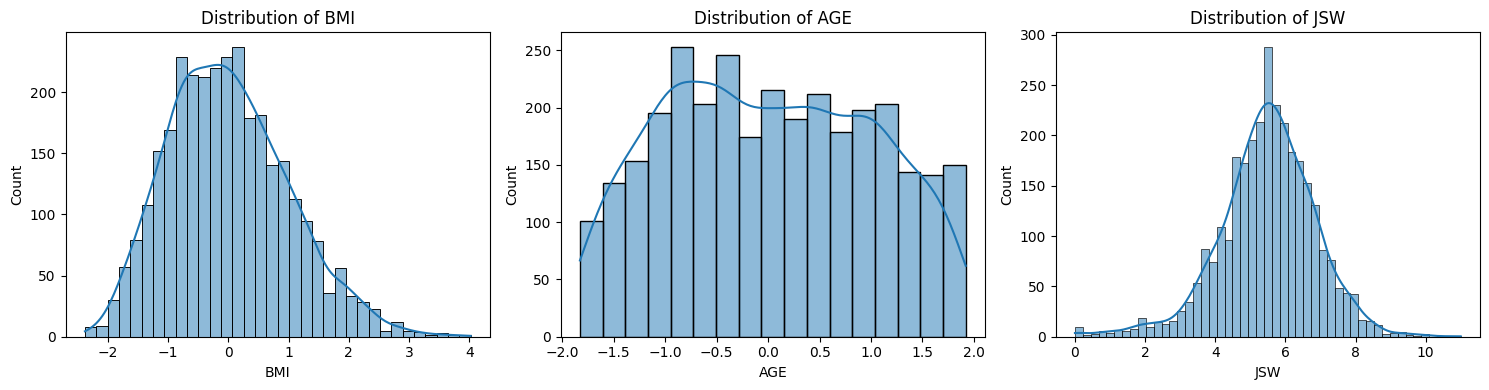

In [33]:
# Plot data (rememeber that you applied normalization to BMI and AGE columns so it's expected that their scale is different)
plot_variables(df1, ['BMI', 'AGE', 'JSW'])

### **Task 1.2: Model Selection and Analysis (3 pts)** 

**Objective**: Use the preprocessed dataset from Task 1.1, then choose an appropriate statistical model to analyze the correlation between BMI, AGE, and JSW (Joint Space Width), with JSW as the response variable, and perform subsequent analyses.

**Given the following options**:

- A) Linear Model ([statsmodels.OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html))
- B) Generalized Linear Model ([statsmodels.GLM.from_formula](https://www.statsmodels.org/dev/generated/statsmodels.genmod.generalized_linear_model.GLM.from_formula.html))
- C) Mixed Linear Model ([statsmodels.MixedLM](https://www.statsmodels.org/stable/generated/statsmodels.regression.mixed_linear_model.MixedLM.html))

**Tasks**:

1. Select the most suitable model and briefly justify your choice.
2. Fit the model using BMI and AGE as predictors and JSW as the response variable. Add an intercept if not included by default.
   - *Note*: Use [statsmodels.add_constant](https://www.statsmodels.org/stable/generated/statsmodels.tools.tools.add_constant.html#statsmodels.tools.tools.add_constant) to add an intercept.
3. Display the summary of the model.
4. Extract the following info from the model:
   - Intercept (β₀)
   - BMI coefficient (β\_BMI)
   - AGE coefficient (β\_AGE)
   - The model degree of freedom


In [102]:
# 1. Select the most suitable model and briefly justify your choice.

# 2. Fit the model using BMI and AGE as predictors and JSW as the response variable. Add an intercept if not included by default.

# 3. Display the summary of the model.

# 4. Extract the following info from the model

Step 1: Model Selection and Justification

A) Linear Model (statsmodels.OLS): Ordinary Least Squares regression, suitable for modeling a linear relationship between predictors (`BMI`, `AGE`) and a continuous response (`JSW`).
B) Generalized Linear Model (statsmodels.GLM.from_formula): Extends linear models to handle non-normal response distributions (e.g., Poisson, logistic). Requires specifying a distribution family.
C) Mixed Linear Model (statsmodels.MixedLM): Accounts for fixed effects (e.g., `BMI`, `AGE`) and random effects (e.g., subject-specific variation), suitable for hierarchical or repeated-measures data.

**My choice is: Linear Model (statsmodels.OLS)**

**Justification:**

Data Characteristics: The preprocessed dataset contains `JSW` (continuous, in mm), `BMI`, and `AGE` (normalized, continuous) for left knees at baseline (`Visit = 0`). There’s no indication of non-normal response distribution or hierarchical structure (e.g., repeated measures per subject), as we’re only using baseline data and one knee per subject.

Simplicity: OLS assumes a linear relationship, which is a reasonable starting point for modeling JSW as a function of BMI and AGE. It’s straightforward and interpretable.

Task Focus: The task emphasizes correlation (linear relationships), and OLS directly estimates regression coefficients (β_BMI, β_AGE) and provides a model summary with degrees of freedom.

Why Not Others?:
GLM: Unnecessary unless `JSW` has a non-normal distribution (e.g., skewed, bounded). The OAI dataset’s `JSW` is typically continuous and approximately normal, so OLS is sufficient.
MixedLM: Relevant for longitudinal data or clustering (e.g., multiple visits or both knees per subject). Since we’re restricted to baseline and one knee, there’s no need for random effects.

In [42]:
# Task 1.1: Preprocessing
def data_preprocessing_task1(df):
    df1 = copy.deepcopy(df)
    df1 = df1[(df1['Visit'] == 0) & (df1['SIDE'] == 'L')]
    df1 = df1[['BMI', 'AGE', 'JSW']]
    df1 = df1.dropna()
    scaler = StandardScaler()
    df1[['BMI', 'AGE']] = scaler.fit_transform(df1[['BMI', 'AGE']])
    return df1

In [44]:
# Task 1.2: Linear Model
def fit_linear_model(df_preprocessed):
    X = df_preprocessed[['BMI', 'AGE']]
    X = sm.add_constant(X)
    y = df_preprocessed['JSW']
    
    model = sm.OLS(y, X)
    results = model.fit()
    
    print(results.summary())
    
    return {
        'intercept': results.params['const'],
        'beta_bmi': results.params['BMI'],
        'beta_age': results.params['AGE'],
        'model_df': results.df_model
    }

In [46]:
# Fit model and get results
df1 = data_preprocessing_task1(df)
results = fit_linear_model(df1)

print("\nExtracted Parameters:")
print(f"Intercept (β₀): {results['intercept']}")
print(f"BMI Coefficient (β_BMI): {results['beta_bmi']}")
print(f"AGE Coefficient (β_AGE): {results['beta_age']}")
print(f"Model Degrees of Freedom: {results['model_df']}")

                            OLS Regression Results                            
Dep. Variable:                    JSW   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     73.19
Date:                Wed, 23 Apr 2025   Prob (F-statistic):           8.76e-32
Time:                        16:31:41   Log-Likelihood:                -5310.2
No. Observations:                3091   AIC:                         1.063e+04
Df Residuals:                    3088   BIC:                         1.064e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4796      0.024    225.803      0.0

---
## **Task 2: Modeling Correlation with Multiple Predictors (4 pts)**

**Scenario**: You have data on **right** knees collected at baseline (Visit = 0). Your goal is to model the correlation between BMI, AGE, SEX, INJ (injury status), and JSW (Joint Space Width), with JSW as the response variable.

### **Task 2.1: Data Preprocessing (1 pt)**
1. Filter the dataset to include only rows where `Visit = 0` and `SIDE = 'R'`.
2. Remove rows with missing values.
3. Retain only the `BMI`, `AGE`, `SEX`, `INJ`, and `JSW` columns.
4. Normalize the `BMI` and `AGE` columns using the StandardScaler:
   - Use `scaler = StandardScaler()`.
   - Apply normalization with `scaler.fit_transform(data)`.

**Hint**: Use `df2 = copy.deepcopy(df)` to create an independent copy of the dataset, preserving the original data for safe preprocessing.

In [49]:
def data_preprocessing_task2(df):
    df2 = copy.deepcopy(df)
    # Filter for Visit = 0 and SIDE = 'R'
    df2 = df2[(df2['Visit'] == 0) & (df2['SIDE'] == 'R')]
    # Retain only BMI, AGE, SEX, INJ, JSW columns
    df2 = df2[['BMI', 'AGE', 'SEX', 'INJ', 'JSW']]
    # Remove rows with missing values
    df2 = df2.dropna()
    # Normalize BMI and AGE using StandardScaler
    scaler = StandardScaler()
    df2[['BMI', 'AGE']] = scaler.fit_transform(df2[['BMI', 'AGE']])
    return df2


df2 = data_preprocessing_task2(df)
display(df2)

,BMI,AGE,SEX,INJ,JSW
0,-1.111837,-0.285380,1.0,0.0,4.32
2,0.128078,0.815502,1.0,0.0,5.44
4,-1.339155,1.035679,0.0,0.0,4.20
6,0.665374,-0.615644,1.0,0.0,6.01
8,0.314065,1.145767,0.0,0.0,3.21
...,...,...,...,...,...
6281,-2.000443,1.145767,0.0,1.0,6.90
6283,-0.223231,1.255855,1.0,1.0,4.77
6285,-0.057909,-1.276174,1.0,0.0,8.01
6287,-1.132502,-0.065203,0.0,0.0,3.85


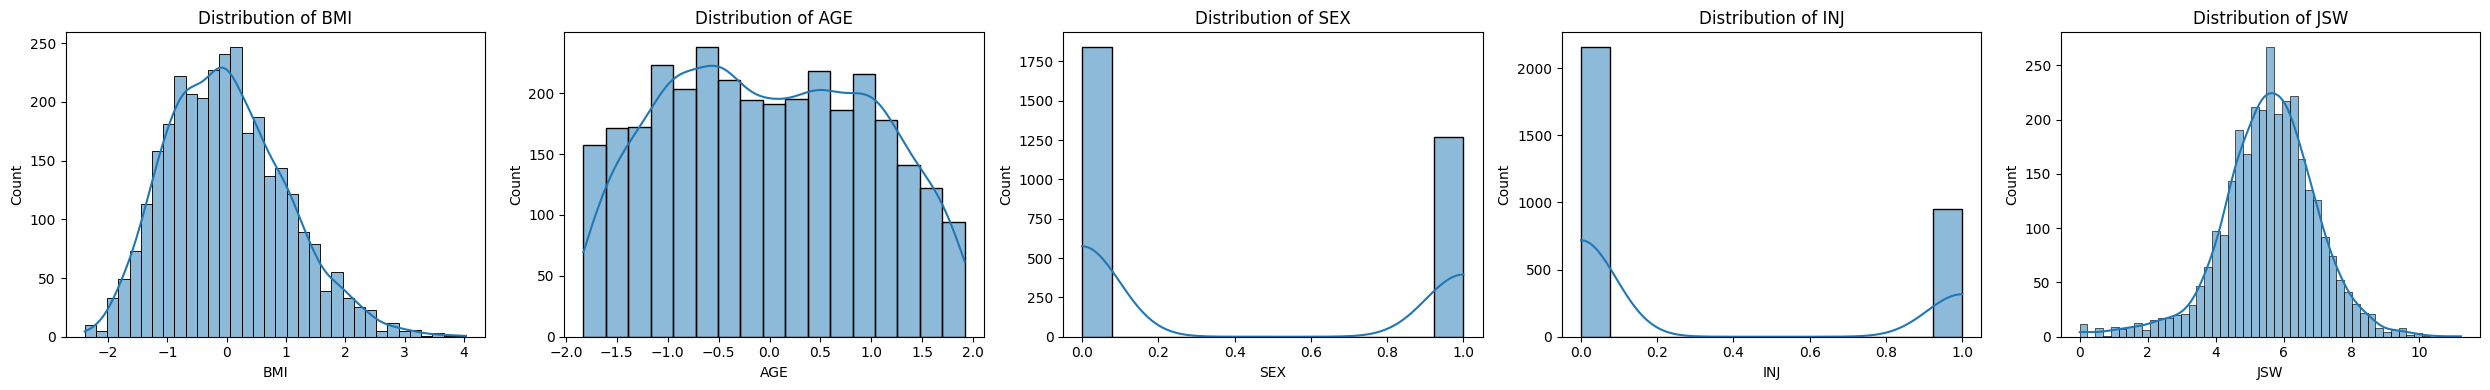

In [51]:
# Plot data (rememeber that you applied normalization to BMI and AGE columns so it's expected that their scale is different)
plot_variables(df2, ['BMI', 'AGE', 'SEX', 'INJ', 'JSW'])

### **Task 2.2: Model Selection and Analysis (3 pts)**

**Objective**: Select an appropriate statistical model to analyze the correlation between BMI, AGE, SEX, INJ (injury status), and JSW (Joint Space Width), with JSW as the response variable.

**Model Choices**:
- A) Linear Model ([`statsmodels.OLS`](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html))
- B) Generalized Linear Model ([`statsmodels.GLM.from_formula`](https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.from_formula.html))
- C) Mixed Linear Model ([`statsmodels.MixedLM`](https://www.statsmodels.org/stable/generated/statsmodels.regression.mixed_linear_model.MixedLM.html))

**Tasks**:
1. Choose the most suitable model and briefly justify your choice.
2. Fit the model using BMI, AGE, SEX, and INJ as predictors and JSW as the response variable. Add an intercept if not included by default.
   - Use [`sm.add_constant`](https://www.statsmodels.org/stable/generated/statsmodels.tools.tools.add_constant.html) to add an intercept, where `X` contains the predictors and `statsmodels` is imported as `sm`.
3. Display the summary of the model, and specify the model degrees of freedom.
4. What predictors are significant in the model? Why?

In [7]:
# 1. Select the most suitable model and briefly justify your choice.

# 2. Fit the model using BMI and AGE as predictors and JSW as the response variable. Add an intercept if not included by default.

# 3. Display the summary of the model, and specify the model degrees of freedom.

# 4. What predictors are significant in the model? Why?

Model Selection and Justification
Options:

A) Linear Model (statsmodels.OLS): Ordinary Least Squares regression, models a linear relationship between predictors (BMI, AGE, SEX, INJ) and a continuous response (JSW).

B) Generalized Linear Model (statsmodels.GLM.from_formula): Handles non-normal response distributions (e.g., Poisson, Gamma) via a link function, requiring a specified family.

C) Mixed Linear Model (statsmodels.MixedLM): Incorporates fixed effects (BMI, AGE, SEX, INJ) and random effects for hierarchical or repeated-measures data.

**My Choice: Linear Model (statsmodels.OLS)**

**Justification:**

Data Characteristics: The preprocessed df2 includes JSW (continuous, in mm), normalized BMI and AGE (continuous), and SEX and INJ (binary: 0.0/1.0). The data is filtered for baseline (Visit = 0) and right knees (SIDE = 'R'), with no repeated measures or clustering (e.g., one observation per subject). OLS is suitable for continuous responses with linear relationships.

Simplicity and Interpretability: OLS assumes linearity, which is a reasonable starting point to model JSW as a function of continuous (BMI, AGE) and binary (SEX, INJ) predictors. It provides straightforward coefficients and p-values for correlation analysis.

Task Focus: The task emphasizes correlation, and OLS directly estimates regression coefficients and significance, aligning with the goal of identifying significant predictors.

In [55]:
# Task 2.1: Preprocessing (for context)
def data_preprocessing_task2(df):
    df2 = copy.deepcopy(df)
    df2 = df2[(df2['Visit'] == 0) & (df2['SIDE'] == 'R')]
    df2 = df2[['BMI', 'AGE', 'SEX', 'INJ', 'JSW']]
    df2 = df2.dropna()
    scaler = StandardScaler()
    df2[['BMI', 'AGE']] = scaler.fit_transform(df2[['BMI', 'AGE']])
    return df2

In [57]:
# Task 2.2: Linear Model
def fit_linear_model_task2(df_preprocessed):
    # Prepare predictors and response
    X = df_preprocessed[['BMI', 'AGE', 'SEX', 'INJ']]
    X = sm.add_constant(X)
    y = df_preprocessed['JSW']
    
    # Fit OLS model
    model = sm.OLS(y, X)
    results = model.fit()
    
    # Display model summary
    print(results.summary())
    
    # Extract model degrees of freedom
    model_df = results.df_model
    
    # Identify significant predictors (p < 0.05)
    significant_predictors = results.pvalues[results.pvalues < 0.05].index.tolist()
    if 'const' in significant_predictors:
        significant_predictors.remove('const')  # Exclude intercept
    
    return {
        'model_df': model_df,
        'significant_predictors': significant_predictors,
        'results': results  # For further analysis if needed
    }

In [59]:
df2 = data_preprocessing_task2(df)
results = fit_linear_model_task2(df2)

# Print results
print(f"\nModel Degrees of Freedom: {results['model_df']}")
print(f"Significant Predictors: {results['significant_predictors']}")

                            OLS Regression Results                            
Dep. Variable:                    JSW   R-squared:                       0.106
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     91.62
Date:                Wed, 23 Apr 2025   Prob (F-statistic):           9.86e-74
Time:                        17:03:34   Log-Likelihood:                -5324.6
No. Observations:                3110   AIC:                         1.066e+04
Df Residuals:                    3105   BIC:                         1.069e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3567      0.034    156.536      0.0

The model summary lists the predictors (BMI, AGE, SEX, INJ) and their p-values (P>|t|). Predictors are considered significant if their p-value is less than 0.05 (standard threshold for statistical significance at the 5% level). From the output:

Significant Predictors: ['BMI', 'AGE', 'SEX', 'INJ']
`BMI: P>|t| = 0.000`
`AGE: P>|t| = 0.000`
`SEX: P>|t| = 0.000`
`INJ: P>|t| = 0.000`
All four predictors are significant, as their p-values are well below `0.05`.

---
## **Task 3: Modeling Correlation with Both Knees (4 pts)**

**Scenario**: You have data on both knees collected at baseline (Visit = 0). Your goal is to model the correlation between BMI, AGE, SEX, INJ, SIDE, and JSW (Joint Space Width), with JSW as the response variable.

### **Task 3.1: Data Preprocessing (1 pt)**
1. Filter the dataset to include only rows where `Visit = 0`.
2. Remove rows with missing values.
3. Retain only the `BMI`, `AGE`, `SEX`, `INJ`, `SIDE`, `ID`, and `JSW` columns.
4. Encode the `SIDE` column by replacing 'L' with 0 and 'R' with 1.
5. Normalize the `BMI` and `AGE` columns using the StandardScaler:
   - Use `scaler = StandardScaler()`.
   - Apply normalization with `scaler.fit_transform(data)`.

**Hint**: Use `df3 = copy.deepcopy(df)` to create an independent copy of the dataset, preserving the original data for safe preprocessing.

In [62]:
def data_preprocessing_task3(df):
    df3 = copy.deepcopy(df)
    # Filter for Visit = 0
    df3 = df3[df3['Visit'] == 0]
    # Retain only BMI, AGE, SEX, INJ, SIDE, ID, JSW columns
    df3 = df3[['BMI', 'AGE', 'SEX', 'INJ', 'SIDE', 'ID', 'JSW']]
    # Remove rows with missing values
    df3 = df3.dropna()
    # Encode SIDE: 'L' -> 0, 'R' -> 1
    df3['SIDE'] = df3['SIDE'].map({'L': 0, 'R': 1})
    # Normalize BMI and AGE using StandardScaler
    scaler = StandardScaler()
    df3[['BMI', 'AGE']] = scaler.fit_transform(df3[['BMI', 'AGE']])
    return df3
    
df3 = data_preprocessing_task3(df)

#display(df3)

# Verify the result
print(df3.head())
print(df3.info())



        BMI       AGE  SEX  INJ  SIDE       ID   JSW
0 -1.108218 -0.285889  1.0  0.0     1  9000099  4.32
1 -1.108218 -0.285889  1.0  1.0     0  9000099  6.10
2  0.129315  0.816361  1.0  0.0     1  9000296  5.44
3  0.129315  0.816361  1.0  1.0     0  9000296  5.44
4 -1.335099  1.036811  0.0  0.0     1  9000622  4.20
<class 'pandas.core.frame.DataFrame'>
Index: 6175 entries, 0 to 6290
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   BMI     6175 non-null   float64
 1   AGE     6175 non-null   float64
 2   SEX     6175 non-null   float64
 3   INJ     6175 non-null   float64
 4   SIDE    6175 non-null   int64  
 5   ID      6175 non-null   int64  
 6   JSW     6175 non-null   float64
dtypes: float64(5), int64(2)
memory usage: 385.9 KB
None


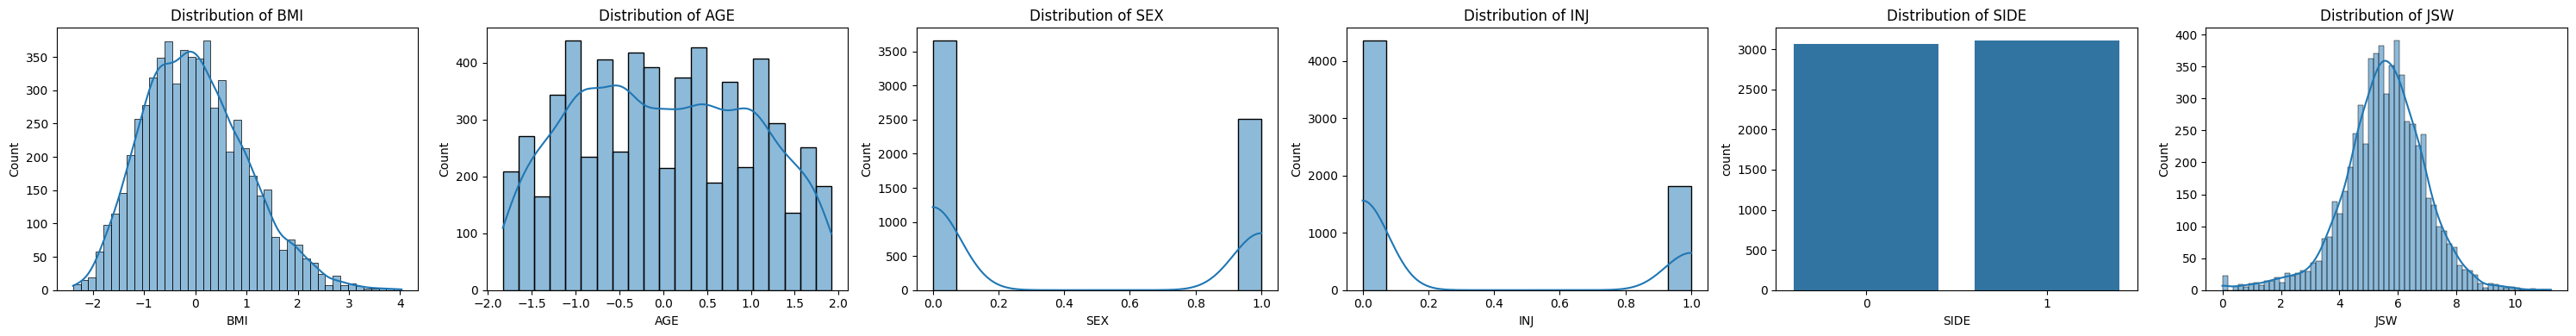

In [64]:
# Plot data (rememeber that you applied normalization to BMI and AGE columns so it's expected that their scale is different)
plot_variables(df3, ['BMI', 'AGE', 'SEX', 'INJ', 'SIDE', 'JSW'])

### **Task 3.2: Model Selection and Analysis (3 pts)**

**Objective**: Select an appropriate statistical model to analyze the correlation between BMI, AGE, SEX, INJ, SIDE, and JSW (Joint Space Width), with JSW as the response variable, considering the effects of `SIDE` and `ID`.

**Model Choices**:
- A) Linear Model ([`statsmodels.OLS`](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html))
- B) Generalized Linear Model ([`statsmodels.GLM.from_formula`](https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.from_formula.html))
- C) Mixed Linear Model ([`statsmodels.MixedLM`](https://www.statsmodels.org/stable/generated/statsmodels.regression.mixed_linear_model.MixedLM.html))

**Tasks**:
1. Choose the most suitable model and briefly justify your choice, considering the roles of `SIDE` (left vs. right knee) and `ID` (individual identifier).
2. Fit the model using `BMI`, `AGE`, `SEX`, `INJ`, and `SIDE` as predictors and `JSW` as the response variable. Account for the effect of `SIDE` and `ID` appropriately (e.g., fixed or random effects for `ID`).
   - Add an intercept if not included by default using [`sm.add_constant`](https://www.statsmodels.org/stable/generated/statsmodels.tools.tools.add_constant.html), where `X` contains the predictors and `statsmodels` is imported as `sm`.
3. Display the model summary.
4. Identify which predictors are statistically significant (e.g., p-value < 0.05).

In [6]:
# 1. Select the most suitable model and briefly justify your choice.

# 2. Fit the model using BMI and AGE as predictors and JSW as the response variable. Add an intercept if not included by default.

# 3. Display the summary of the model.

# 4. Identify which predictors are statistically significant

**Choice: Mixed Linear Model (statsmodels.MixedLM)**

Justification:

Data Structure: The dataset includes both knees (SIDE = 0 or 1) per subject (ID) at baseline (Visit = 0). Observations from the same subject (left and right knees) are correlated, as knee measurements within an individual are likely more similar than between individuals. A MixedLM can model this by including a random effect for ID, accounting for within-subject correlation.

Role of SIDE: SIDE (left vs. right knee) is a binary predictor (0/1) that may influence JSW due to biomechanical differences. It’s best treated as a fixed effect, as we’re interested in estimating its specific effect on JSW.

Response Variable: JSW is continuous (in mm), and while slight non-normality was noted in previous tasks (e.g., Task 2.2), MixedLM assumes normality of residuals, which is reasonable for large samples (~6000 observations).

Why Not Others?:
OLS: Ignores the correlation between knees within subjects, potentially leading to biased standard errors and incorrect p-values, as it assumes independence of observations.

GLM: Suitable for non-normal responses (e.g., skewed JSW), but there’s no strong evidence JSW requires a non-normal distribution, and GLM doesn’t handle clustering by ID.

In [74]:
# Task 3.2: Mixed Linear Model

model = smf.mixedlm("JSW ~ BMI + AGE + SEX + INJ + SIDE", data=df3, groups=df3["ID"])
results = model.fit()
    
#Display summary
print(results.summary())
    
# Signnificant predictors
# All the predictors (BMI, AGE, SEX, INJ, and SIDE) are statistically significant i.e. p<0.05   

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: JSW        
No. Observations: 6175    Method:             REML       
No. Groups:       3433    Scale:              0.9186     
Min. group size:  1       Log-Likelihood:     -10150.9315
Max. group size:  4       Converged:          Yes        
Mean group size:  1.8                                    
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      5.312    0.030 176.512 0.000  5.253  5.371
BMI           -0.096    0.020  -4.795 0.000 -0.136 -0.057
AGE           -0.281    0.020 -13.988 0.000 -0.320 -0.241
SEX            0.703    0.041  17.276 0.000  0.624  0.783
INJ           -0.404    0.035 -11.585 0.000 -0.472 -0.336
SIDE           0.101    0.025   4.008 0.000  0.052  0.150
Group Var      0.832    0.050                            



---
## **Task 4: Modeling Correlation with Both Knees and All Visits (3 pts)**

**Scenario**: You have data on both knees collected at all visits. Your goal is to model the correlation between BMI, AGE, SEX, INJ, SIDE, and JSW (Joint Space Width), with JSW as the response variable.

### **Task 4.1: Data Preprocessing (1 pt)**
1. Create the dataframe for both knees of all subjects.
2. Remove rows with missing values.
3. Retain only the `BMI`, `AGE`, `SEX`, `INJ`, `SIDE`, `ID`, and `JSW` columns.
4. Encode the `SIDE` column by replacing 'L' with 0 and 'R' with 1.
5. Normalize the `BMI` and `AGE` columns using the StandardScaler:
   - Use `scaler = StandardScaler()`.
   - Apply normalization with `scaler.fit_transform(data)`.

**Hint**: Use `df4 = copy.deepcopy(df)` to create an independent copy of the dataset, preserving the original data for safe preprocessing.

In [77]:
# Task 3.1: Preprocessing
def data_preprocessing_task3(df):
    df3 = copy.deepcopy(df)
    df3 = df3[df3['Visit'] == 0][['BMI', 'AGE', 'SEX', 'INJ', 'SIDE', 'ID', 'JSW']].dropna()
    df3['SIDE'] = df3['SIDE'].map({'L': 0, 'R': 1})
    scaler = StandardScaler()
    df3[['BMI', 'AGE']] = scaler.fit_transform(df3[['BMI', 'AGE']])
    return df3


### **Task 4.2: Model Selection and Analysis (2 pts)**

**Objective**: Select an appropriate statistical model to analyze the correlation between BMI, AGE, SEX, INJ, SIDE, and JSW (Joint Space Width), with JSW as the response variable, considering the effects of `SIDE` and `ID`.

**Model Choices**:
- A) Linear Model ([`statsmodels.OLS`](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html))
- B) Generalized Linear Model ([`statsmodels.GLM.from_formula`](https://www.statsmodels.org/stable/generated/statsmodels.genmod.generalized_linear_model.GLM.from_formula.html))
- C) Mixed Linear Model ([`statsmodels.MixedLM`](https://www.statsmodels.org/stable/generated/statsmodels.regression.mixed_linear_model.MixedLM.html))

**Tasks**:
1. Choose the most suitable model and briefly justify your choice, considering the roles of `SIDE` (left vs. right knee) and `ID` (individual identifier).
2. Fit the model using `BMI`, `AGE`, `SEX`, `INJ`, and `SIDE` as predictors and `JSW` as the response variable. Account for the effect of `SIDE` and `ID` appropriately (e.g., fixed or random effects for `ID`).
   - Add an intercept if not included by default using [`sm.add_constant`](https://www.statsmodels.org/stable/generated/statsmodels.tools.tools.add_constant.html), where `X` contains the predictors and `statsmodels` is imported as `sm`.
3. Display the summary of the model, and specify the model degrees of freedom.
4. Identify which predictors are statistically significant (e.g., p-value < 0.05).

In [85]:

# Task 3.2: Mixed Linear Model

    # Fit MixedLM using formula
model = smf.mixedlm("JSW ~ BMI + AGE + SEX + INJ + SIDE", data=df3, groups=df3["ID"])
results = model.fit()
    
# Display summary
print(results.summary())

# Significant predictors
# All the predictors (BMI, AGE, SEX, INJ, and SIDE) are statistically significant i.e. p<0.05

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: JSW        
No. Observations: 6175    Method:             REML       
No. Groups:       3433    Scale:              0.9186     
Min. group size:  1       Log-Likelihood:     -10150.9315
Max. group size:  4       Converged:          Yes        
Mean group size:  1.8                                    
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      5.312    0.030 176.512 0.000  5.253  5.371
BMI           -0.096    0.020  -4.795 0.000 -0.136 -0.057
AGE           -0.281    0.020 -13.988 0.000 -0.320 -0.241
SEX            0.703    0.041  17.276 0.000  0.624  0.783
INJ           -0.404    0.035 -11.585 0.000 -0.472 -0.336
SIDE           0.101    0.025   4.008 0.000  0.052  0.150
Group Var      0.832    0.050                            



### **Mixed Linear Model (statsmodels.MixedLM):** This is the correct choice. Mixed models are specifically designed to handle data where observations are not independent. 

They do this by including:

**Fixed Effects:** These are the predictors of primary interest (BMI, AGE, SEX, INJURY, SIDE). We want to estimate the average effect of these variables on JSW across the population.


**Random Effects:** This is how we account for the non-independence. We treat ID as a random effect. This allows the model to recognize that JSW values tend to be more similar within the same individual than between different individuals. It essentially allows each individual to have their own "baseline" JSW, and the model then looks at how the other predictors cause variation around that individual baseline. 


The Mixed Linear Model is essential because it correctly addresses the correlated nature of the data due to repeated measures (left and right knees) within the same individual

**Linear Model** (statsmodels.OLS): This is the basic linear regression. It assumes independence of observations. **It would be inappropriate here** because the JSW measurements for left and right knees within the same patient are correlated. This violates the independence assumption.    


**Generalized Linear Model** (statsmodels.GLM.from_formula): GLMs are used when the response variable doesn't follow a normal distribution (e.g., binary outcomes, count data). Since JSW is a continuous measurement, a GLM isn't the primary choice, although it could be adapted under certain transformations. However, it still doesn't inherently handle the non-independence of observations within individuals.    


In [5]:
# 1. Select the most suitable model and briefly justify your choice.

# 2. Fit the model using BMI and AGE as predictors and JSW as the response variable. Add an intercept if not included by default.

# 3. Display the summary of the model

# 4. Identify which predictors are statistically significant